# A/B Testing Marketing Project

## 1. Business Understanding
Objective: Determine which marketing campaign variant (A or B) drives higher engagement and conversion.

#### Business questions:
1. Which campaign version leads to higher conversion rates?
2. Does the winning variant increase revenue per user?
3. Are there demographic segments that respond differently to the campaigns?
4. Success criteria:
5. Statistically significant lift in conversion rate for one variant
6. Positive impact on secondary metrics (click-through rate, revenue per user)
7. Actionable recommendation for campaign rollout

## 2. Data Understanding
- Dataset sources:
- Messy marketing dataset from kaggle.
- Columns include:
- user_id – unique identifier
- group – control or variant
- clicks – number of clicks per user
- views – number of ad views
- converted – 1 if converted, 0 otherwise
- age, gender, location – demographic info

In [22]:
# import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [23]:
# Load data from a CSV file and print the first 5 rows
data = pd.read_csv('marketing_AB.csv')

In [24]:
# Display the first 5 rows of the dataset
data.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [25]:
# Display the last 5 rows of the dataset
data.tail()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23
588100,588100,1237779,ad,False,1,Tuesday,23


In [26]:
# check the shape of the dataset
data.shape

(588101, 7)

In [27]:
# check the info of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [28]:
# check the data types of each column
data.dtypes

Unnamed: 0        int64
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

In [29]:
#check statistical summary of the dataset
data.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [30]:
# check for missing values
data.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [31]:
# check for unique values in each column
data.nunique()

Unnamed: 0       588101
user id          588101
test group            2
converted             2
total ads           807
most ads day          7
most ads hour        24
dtype: int64

In [32]:
# check for duplicate rows
data.duplicated().sum()

0

Text(0.5, 0, 'Test Group')

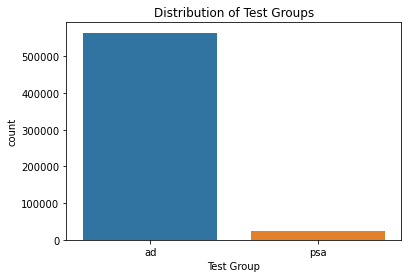

In [33]:
# check of imbalanced test groups
data['test group'].value_counts()
# visualize the distribution of test groups
plt.figure(figsize=(6, 4))
sns.countplot(x='test group', data=data)
plt.title('Distribution of Test Groups')
plt.xlabel('Test Group')

#### conclusions
1. the data doesn't have missing values
2. The data doesn't have duplicated rows

## EDA

In [34]:
# Rename columns for better readability
data = data.rename(columns={
    'user id': 'user_id',
    'test group': 'test_group',
    'converted': 'converted',
    'total ads' : 'total_ads',
    'most ads day': 'most_ads_day',
    'most ads hour': 'most_ads_hour'
})

Text(0, 0.5, 'Conversion Rate')

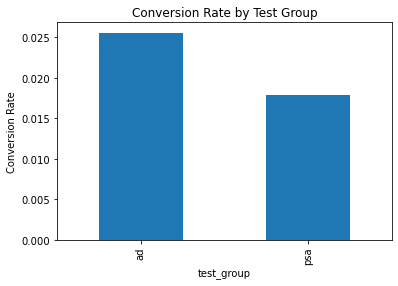

In [35]:
# conversion rate by test group
conversion_rate = data.groupby('test_group')['converted'].mean()
conversion_rate.plot(kind='bar', title='Conversion Rate by Test Group')
plt.ylabel('Conversion Rate')

<AxesSubplot:xlabel='total_ads', ylabel='Count'>

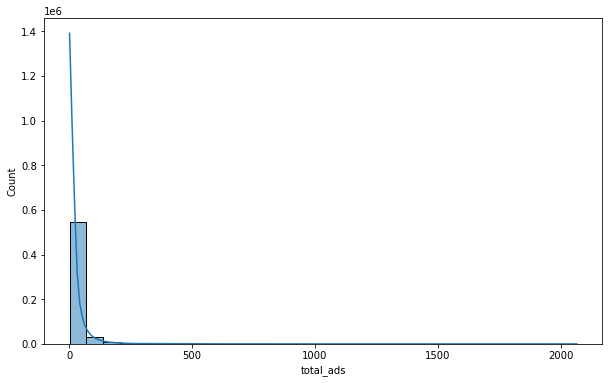

In [36]:
# Distribution of total ads seen
plt.figure(figsize=(10, 6))
sns.histplot(data['total_ads'], bins=30, kde=True)  

Text(0, 0.5, 'Conversion Rate')

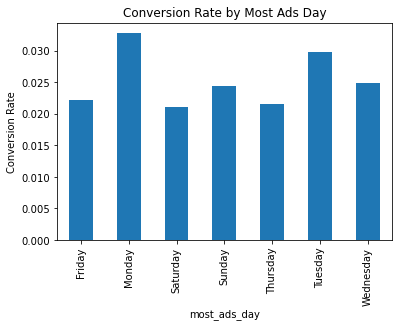

In [37]:
# conversion rate by most ads day
conversion_rate_day = data.groupby('most_ads_day')['converted'].mean()
conversion_rate_day.plot(kind='bar', title='Conversion Rate by Most Ads Day')
plt.ylabel('Conversion Rate')

Text(0, 0.5, 'Conversion Rate')

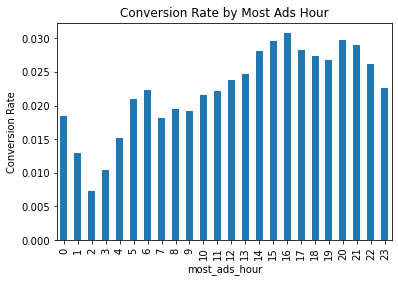

In [38]:
# conversion rate by most ads per hour
conversion_rate_hour = data.groupby('most_ads_hour')['converted'].mean()
conversion_rate_hour.plot(kind='bar', title='Conversion Rate by Most Ads Hour')
plt.ylabel('Conversion Rate')


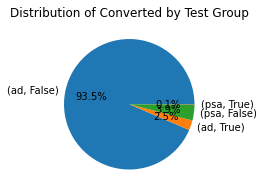

In [39]:
grouped_counts = data.groupby('test_group')['converted'].value_counts()
grouped_counts

# Plot the data as a pie chart
grouped_counts.plot.pie(figsize= (3,3),autopct='%1.1f%%')

# Set the title and axis labels
plt.title('Distribution of Converted by Test Group')
plt.ylabel('')

# Show the plot
plt.show()

### 3. Data Preparation

In [40]:
# check for the uniformity of column names
data.columns

Index(['Unnamed: 0', 'user_id', 'test_group', 'converted', 'total_ads',
       'most_ads_day', 'most_ads_hour'],
      dtype='object')

In [41]:
data = data.drop(columns=['Unnamed: 0'])
data.columns

Index(['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day',
       'most_ads_hour'],
      dtype='object')

In [42]:
#


In [43]:
# convert the 'converted' column to integer type (1 for True, 0 for False)
data["converted_int"] = data['converted'].apply(lambda x:1 if x== True  else  0)
data["converted_int"].sum()

14843

In [44]:
data.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour,converted_int
0,1069124,ad,False,130,Monday,20,0
1,1119715,ad,False,93,Tuesday,22,0
2,1144181,ad,False,21,Tuesday,18,0
3,1435133,ad,False,355,Tuesday,10,0
4,1015700,ad,False,276,Friday,14,0


## A/B Testing

In [ ]:
import math

def sample_size_calculator(population_size, confidence_level, margin_of_error):
    z_score = {
        0.90: 1.645,
        0.95: 1.96,
        0.99: 2.576
    }
    
    z = z_score[confidence_level]
    p = 0.5 # assuming 50% for a conservative estimate of the sample size
    q = 1 - p
    
    sample_size = ((z**2) * p * q * population_size) / ((z**2 * q) + ((margin_of_error**2) * (population_size - 1)))
    return math.ceil(sample_size)

In [46]:
#compute sample size 
pop_size = data.shape[0]
conf_level = 0.99
margin_err = 0.03

sample_size = sample_size_calculator(pop_size, conf_level, margin_err)
print(f"The population size is :{pop_size} \nThe required sample size is: {sample_size}")

The population size is :588101 
The required sample size is: 1832


In [ ]:
# Perform a t-test to compare the means of the two groups
treatment = data.query('test_group == "ad"')
control = data.query('test_group == "psa"')

In [48]:
data.converted.mean() *100

2.523886203220195

In [49]:
control["converted"].mean()

0.01785410644448223

In [50]:
treatment["converted"].mean()

0.025546559636683747

mean of converted in treatment group is more than control group which make the hypothsis of ad has positive effect on conversion

(array([  2.,   1.,   0.,   2.,   3.,  18.,  21.,  28.,  35.,  48.,  78.,
        113., 118., 144., 226., 249., 317., 375., 454., 520., 568., 606.,
        572., 659., 594., 635., 569., 518., 451., 412., 327., 323., 260.,
        204., 141., 123.,  90.,  69.,  40.,  22.,  27.,  15.,   7.,   4.,
          4.,   5.,   2.,   0.,   0.,   1.]),
 array([0.02446788, 0.02450036, 0.02453284, 0.02456533, 0.02459781,
        0.0246303 , 0.02466278, 0.02469527, 0.02472775, 0.02476024,
        0.02479272, 0.02482521, 0.02485769, 0.02489017, 0.02492266,
        0.02495514, 0.02498763, 0.02502011, 0.0250526 , 0.02508508,
        0.02511757, 0.02515005, 0.02518253, 0.02521502, 0.0252475 ,
        0.02527999, 0.02531247, 0.02534496, 0.02537744, 0.02540993,
        0.02544241, 0.0254749 , 0.02550738, 0.02553986, 0.02557235,
        0.02560483, 0.02563732, 0.0256698 , 0.02570229, 0.02573477,
        0.02576726, 0.02579974, 0.02583222, 0.02586471, 0.02589719,
        0.02592968, 0.02596216, 0.02599465, 0.

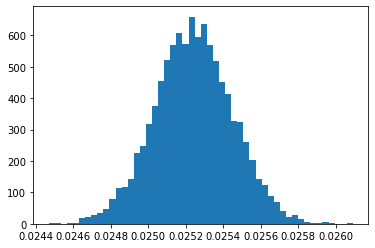

In [ ]:
# simulates the sampling distribution of a conversion rate under a binomial process and then visualizes it.
ad_converted = np.random.binomial(len(treatment),
                                  data.converted.mean(), 10000) / len(treatment)

plt.hist(ad_converted, bins=50)

(array([  3.,   1.,   3.,   3.,   7.,  11.,  19.,  19.,  30.,  48.,  74.,
         74., 134., 178., 237., 203., 337., 394., 472., 396., 558., 630.,
        674., 464., 678., 634., 471., 588., 555., 455., 268., 341., 253.,
        230., 114., 134., 102.,  66.,  40.,  37.,  30.,  12.,  13.,   2.,
          3.,   2.,   1.,   0.,   1.,   1.]),
 array([0.02142493, 0.02158391, 0.0217429 , 0.02190189, 0.02206087,
        0.02221986, 0.02237885, 0.02253783, 0.02269682, 0.02285581,
        0.02301479, 0.02317378, 0.02333277, 0.02349175, 0.02365074,
        0.02380973, 0.02396871, 0.0241277 , 0.02428669, 0.02444567,
        0.02460466, 0.02476365, 0.02492263, 0.02508162, 0.02524061,
        0.02539959, 0.02555858, 0.02571757, 0.02587655, 0.02603554,
        0.02619452, 0.02635351, 0.0265125 , 0.02667148, 0.02683047,
        0.02698946, 0.02714844, 0.02730743, 0.02746642, 0.0276254 ,
        0.02778439, 0.02794338, 0.02810236, 0.02826135, 0.02842034,
        0.02857932, 0.02873831, 0.0288973 , 0.

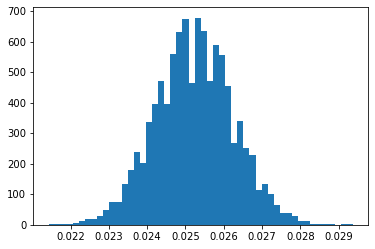

In [ ]:
# is buying less is
psa_converted = np.random.binomial(len(control),
                                   data.converted.mean(), 10000) / len(control)

plt.hist(psa_converted, bins=50 ,align = 'mid' , data=None)

In [ ]:
# Calculate the difference in mean conversion rates between the treatment and control groups
p_diffs = ad_converted - psa_converted
p_diffs
p_diffs.mean()

8.915821690589642e-06

In [54]:
# customer who is shown ads bought less
ab_data_diff = treatment['converted'].mean() - control['converted'].mean()
ab_data_diff

0.007692453192201517

Does showing ads to people lead to more purchases? Is this statistically significant or not? Null Hypothesis (H0): Showing ads has no significant effect on the number of purchases. Alternative Hypothesis (H1): Showing ads has a significant effect on the number of purchases.

In [ ]:
# is buying less is significant?
if ab_data_diff > 0 : 
    p_value = (p_diffs > ab_data_diff).mean() * 100
else :
    p_value = (p_diffs <= ab_data_diff).mean() * 100
print ( "p_value = " ,p_value)
if p_value < 0.05:
    print( 'Reject the null hypothesis. There is a significant difference between the two groups.')
else:
    print( 'Fail to reject the null hypothesis. There is no significant difference between the two groups.')

p_value =  0.0
Reject the null hypothesis. There is a significant difference between the two groups.


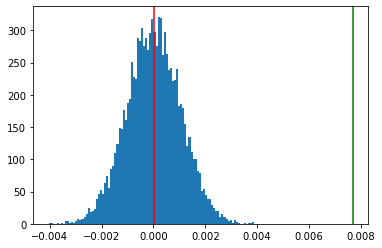

In [ ]:
# Visualize the distribution of the differences in means and the observed difference    
plt.hist(p_diffs, bins=100)
low = ab_data_diff
higth = p_diffs.mean()
plt.axvline(x=low, color='g')
plt.axvline(x=higth, color='r')

### AB test using Code Simulation

In [ ]:
# Perform a t-test to compare the means of the two groups
treatment = data.query('test_group == "ad"')
control = data.query('test_group == "psa"')

In [ ]:
# Calculate the difference in mean conversion rates between the treatment and control groups
dif = treatment["converted"].mean() - control["converted"].mean()
dif

0.007692453192201517

In [ ]:
# Bootstrap sampling to create distributions of the mean converted column for both test groups
conversion = np.array([
    np.append(np.zeros(len(control["converted"])), np.ones(len(treatment["converted"]))),
    np.append(control["converted"],treatment["converted"])
])
conversion_t = conversion.T
conversion_t

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [ ]:
# Function to perform the experiment and calculate the difference in means for N iterations
def sh_exp(N):
    experiment_diff_mean = np.empty([N, 1])
    for times in np.arange(N):
        experiment_label = np.random.randint(0, 2, len(conversion_t))
        experiment_data = np.array([
            experiment_label,
            conversion_t[:, 1]
        ]).T
        experiment_diff_mean[times] = experiment_data[experiment_data[:, 0] == 1][:, 1].mean() - experiment_data[experiment_data[:, 0] == 0][:, 1].mean()
    return experiment_diff_mean

In [ ]:
# Perform the experiment and calculate the p-value
import random
n=2000
p_difs = sh_exp(n)

if dif > 0  : 
    p_value = len(p_difs[p_difs >= dif]) / n * 100
else : 
    p_value = len(p_difs[p_difs <= dif]) / n * 100
    
if p_value < 0.05:
    print( 'Reject the null hypothesis. There is a significant difference between the two groups.')
else:
    print( 'Fail to reject the null hypothesis. There is no significant difference between the two groups.')

Reject the null hypothesis. There is a significant difference between the two groups.


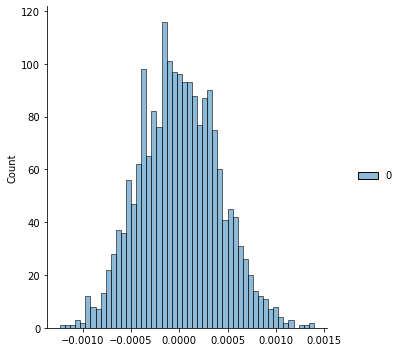

In [63]:
sns.displot(p_difs, bins=50)

T-Test

#### Check the distribution of the two groups by KDE

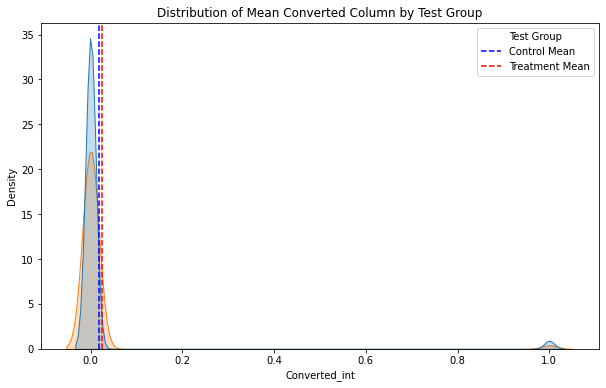

In [67]:
# Visualize the distribution of the 'converted' column for both test groups
control_mean = data.loc[data['test_group'] == 'psa', 'converted_int'].mean()
treatment_mean = data.loc[data['test_group'] == 'ad', 'converted_int'].mean()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='converted_int', hue='test_group', fill=True, common_norm=False)
plt.axvline(control_mean, color='b', linestyle='--', label='Control Mean')
plt.axvline(treatment_mean, color='r', linestyle='--', label='Treatment Mean')
plt.title('Distribution of Mean Converted Column by Test Group')
plt.xlabel('Converted_int')
plt.ylabel('Density')
plt.legend(title='Test Group')
plt.show()


### check distribution using boost Trap

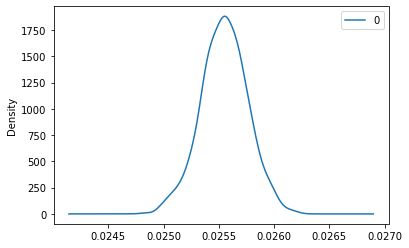

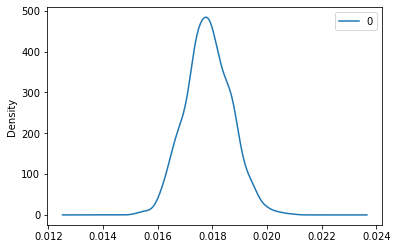

In [ ]:
# Bootstrap sampling to create distributions of the mean converted column for both test groups
boot_treatment=[]
for i in range(1000):
    boot_mean = treatment.sample(frac=1, replace=True)['converted_int'].mean()
    boot_treatment.append(boot_mean)
boot_treatment=pd.DataFrame(boot_treatment)
boot_treatment.plot(kind='density');

boot_control=[]

for i in range(1000):
    boot_mean=control.sample(frac=1,replace=True)['converted_int'].mean()
    boot_control.append(boot_mean)
    
boot_control=pd.DataFrame(boot_control)
boot_control.plot(kind='density');
    

In [ ]:
# Perform a t-test to compare the means of the two groups
from scipy import stats
def t_test(treatment_data, control_data) :
    
    t_statistic, p_value = stats.ttest_ind(treatment_data, control_data)
    print("T-statistic:", t_statistic)
    print("P-value:", p_value)
    
    if p_value < 0.05 :    
        print( 'Reject the null hypothesis. There is a significant difference between the two groups.')
    else:
        print( 'Fail to reject the null hypothesis. There is no significant difference between the two groups.')

    return t_statistic, p_value
    

# Perform a t-test to compare the means of the two groups
t_statistic, p_value = t_test(treatment["converted"], control["converted"])


T-statistic: 7.37040597428566
P-value: 1.7033052627831264e-13
Reject the null hypothesis. There is a significant difference between the two groups.


### Chi test

Does the display of advertisements correlate with the number of purchases or not?

In [ ]:
# Interpret the results 
ct = pd.crosstab(data['test_group'], data['converted'], margins=True)


ct

converted,False,True,All
test_group,,,
ad,550154,14423,564577
psa,23104,420,23524
All,573258,14843,588101


In [71]:
d = np.array([ct.iloc[0][: -1].values, ct.iloc[1][: -1].values])
d

array([[550154,  14423],
       [ 23104,    420]], dtype=int64)

In [72]:
chi2, p_value, dof, expected  =stats.chi2_contingency(ct)

# Print the results
print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Chi-square statistic: 54.318051591383124
P-value: 4.5144265218984724e-11
Degrees of freedom: 4
Expected frequencies:
[[550327.71899045  14249.28100955 564577.        ]
 [ 22930.28100955    593.71899045  23524.        ]
 [573258.          14843.         588101.        ]]


Reject the null hypothesis. There is a significant difference between the two groups.


Text(51.0, 0.5, 'Test Group')

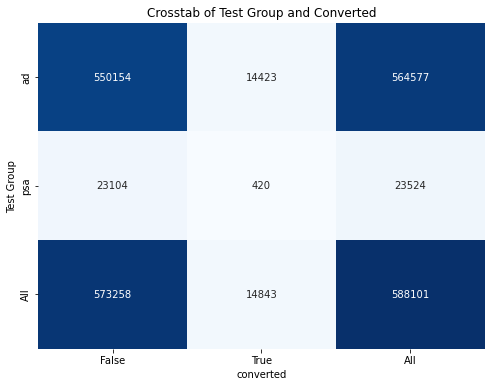

In [ ]:
# Interpret the results
if p_value < 0.05:
    print ( 'Reject the null hypothesis. There is a significant difference between the two groups.')
else:
    print ('Fail to reject the null hypothesis. There is no significant difference between the two groups.')
# Visualize the crosstab as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Crosstab of Test Group and Converted')
plt.ylabel('Test Group')


The ad group achieved a higher conversion rate of 2.62% compared to the PSA group's 1.81%. This indicates that the ad campaign was more effective in driving conversions compared to the PSA.

The t-test p-value of 0.0000 indicates that the difference in conversion rates between the two groups is statistically significant, meaning that it is highly unlikely to have occurred by chance alone. This provides strong evidence for the observed difference between the two groups.